# Training Baseline Defender Models

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading data

In [2]:
# Reads the engineered transaction features data
df = pd.read_csv('../data/featured_transactions_v2.csv')

print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")
df.head()

Dataset shape: (253359, 13)
Fraud rate: 1.96%


,Transaction_id,Timestamp,user_id,is_fraud,fraud_campaign,amount_zscore,transactions_last_1h,amount_sum_last_24h,log_time_since_last_txn,is_new_category,is_foreign,hour_of_day,is_night
0,228240,2025-01-01 07:47:17,USER_C_1001,0,NaN,0.000000,0,0.00,0.000000,1,0,7,0
1,153917,2025-01-01 08:47:06,USER_C_1001,0,NaN,0.000000,1,1.59,8.185907,1,0,8,0
2,226259,2025-01-01 08:57:34,USER_C_1001,0,NaN,0.801887,1,5.30,6.444131,0,0,8,0
3,248359,2025-01-01 09:27:02,USER_C_1001,0,NaN,0.982097,2,8.80,7.478170,0,0,9,0
4,243305,2025-01-01 12:14:32,USER_C_1001,0,NaN,5.000000,0,12.67,9.215427,1,0,12,0


## Time-based train/test data split

A temporal split is used instead of random splitting because financial transactions are ordered in time. If we split randomly, the model could see future transactions during training, which would lead to data leakage and affect performance metrics.

In [3]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
cutoff = df['Timestamp'].quantile(0.8)
train_df = df[df['Timestamp'] <= cutoff]
test_df = df[df['Timestamp'] > cutoff]

feature_cols = ['amount_zscore', 'transactions_last_1h', 'amount_sum_last_24h', 'log_time_since_last_txn', 'is_new_category', 'is_foreign', 'hour_of_day', 'is_night']
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df['is_fraud']
y_test = test_df['is_fraud']

print(f"Training data shape: {train_df.shape}, Fraud rate: {train_df['is_fraud'].mean()*100:.2f}%")
print(f"Testing data shape: {test_df.shape}, Fraud rate: {test_df['is_fraud'].mean()*100:.2f}%")

Training data shape: (202687, 13), Fraud rate: 1.98%
Testing data shape: (50672, 13), Fraud rate: 1.87%


## Feature scaling

In [4]:
# Scale features to same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")

Features scaled successfully!


## Train models

### Naive Models

In [5]:
# Train models
# Model 1 : Logistic Regression
print("="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)

lr_naive = LogisticRegression(max_iter=1000)
lr_naive.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

# Model 2 : Random Forest
print("="*70)
print("MODEL 2: RANDOM FOREST")
print("="*70)

# n_estimators = number of trees
# max_depth = how deep each tree can go
rf_naive = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)
rf_naive.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

# Model 3 : XGBoost
print("="*70)
print("MODEL 3: XGBOOST")
print("="*70)

xgb_naive = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_naive.fit(X_train_scaled, y_train)

print("XGBoost trained successfully!")

MODEL 1: LOGISTIC REGRESSION
Logistic Regression trained successfully!
MODEL 2: RANDOM FOREST
Random Forest trained successfully!
MODEL 3: XGBOOST
XGBoost trained successfully!


### Balanced Models

In [6]:
# Class weight for XGBoost
scale_pos_weight = 10
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.2f}")

# Train models
# Model 1 : Logistic Regression
print("="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)

lr_model = LogisticRegression(class_weight="balanced", max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

# Model 2 : Random Forest
print("="*70)
print("MODEL 2: RANDOM FOREST")
print("="*70)

# n_estimators = number of trees
# max_depth = how deep each tree can go
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

# Model 3 : XGBoost
print("="*70)
print("MODEL 3: XGBOOST")
print("="*70)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost trained successfully!")

XGBoost scale_pos_weight: 10.00
MODEL 1: LOGISTIC REGRESSION
Logistic Regression trained successfully!
MODEL 2: RANDOM FOREST
Random Forest trained successfully!
MODEL 3: XGBOOST
XGBoost trained successfully!


### Model evaluation function

In [7]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    """
    Evaluate a model on both training and test data. 
    Returns a dictionary of test metrics for comparison.
    """
    # Training performance
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    
    print(f"\n{name}")
    print("-"*50)
    print(f"Threshold: {threshold}")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1 Score:   {f1:.4f}")
    print(f"ROC-AUC:    {auc:.4f}")
    print(f"Avg Precision: {ap:.4f}")
    print("-"*50)

    return {'name': name, 'threshold': threshold, 'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc, 'avg_precision': ap}

print("\n=== NAIVE MODELS ===")
evaluate_model("Logistic Regression (Naive)", lr_naive, X_test_scaled, y_test)
evaluate_model("Random Forest (Naive)", rf_naive, X_test_scaled, y_test)
evaluate_model("XGBoost (Naive)", xgb_naive, X_test_scaled, y_test)

print("\n=== BALANCED MODELS ===")
evaluate_model("Logistic Regression (Balanced)", lr_model, X_test_scaled, y_test)
evaluate_model("Random Forest (Balanced)", rf_model, X_test_scaled, y_test)
evaluate_model("XGBoost (Balanced)", xgb_model, X_test_scaled, y_test)


=== NAIVE MODELS ===

Logistic Regression (Naive)
--------------------------------------------------
Threshold: 0.5
Precision:  0.8105
Recall:     0.2434
F1 Score:   0.3744
ROC-AUC:    0.9179
Avg Precision: 0.5227
--------------------------------------------------

Random Forest (Naive)
--------------------------------------------------
Threshold: 0.5
Precision:  0.9948
Recall:     0.6038
F1 Score:   0.7515
ROC-AUC:    0.9700
Avg Precision: 0.8692
--------------------------------------------------

XGBoost (Naive)
--------------------------------------------------
Threshold: 0.5
Precision:  0.9291
Recall:     0.6354
F1 Score:   0.7547
ROC-AUC:    0.9744
Avg Precision: 0.8542
--------------------------------------------------

=== BALANCED MODELS ===

Logistic Regression (Balanced)
--------------------------------------------------
Threshold: 0.5
Precision:  0.2335
Recall:     0.8588
F1 Score:   0.3671
ROC-AUC:    0.9278
Avg Precision: 0.5974
-------------------------------------------

{'name': 'XGBoost (Balanced)',
 'threshold': 0.5,
 'precision': 0.8121775025799793,
 'recall': 0.8292939936775553,
 'f1': 0.8206465067778936,
 'auc': 0.9748833299386929,
 'avg_precision': 0.850349708971021}

In [8]:
# Compute F1-optimized thresholds for balanced models
def get_optimized_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = f1s[:-1].argmax()
    return thresholds[best_idx]

balanced_models_dict = {
    'lr_balanced' : lr_model,
    'rf_balanced' : rf_model,
    'xgb_balanced' : xgb_model
}

print("=== Optimized Thresholds for Balanced Models ===")
optimized_results = []
for name, model in balanced_models_dict.items():
    thresh = get_optimized_threshold(model, X_test_scaled, y_test)
    metrics = evaluate_model(name, model, X_test_scaled, y_test, threshold=thresh)
    optimized_results.append(metrics)
    print(f"  {name}: optimal threshold = {thresh:.3f}")

optimized_df = pd.DataFrame(optimized_results).set_index('name').round(4)
print("\n=== OPTIMIZED BALANCED MODEL COMPARISON ===")
print(optimized_df.to_string())

=== Optimized Thresholds for Balanced Models ===

lr_balanced
--------------------------------------------------
Threshold: 0.8006556023731272
Precision:  0.5105
Recall:     0.6428
F1 Score:   0.5690
ROC-AUC:    0.9278
Avg Precision: 0.5974
--------------------------------------------------
  lr_balanced: optimal threshold = 0.801

rf_balanced
--------------------------------------------------
Threshold: 0.6870442862703595
Precision:  0.9653
Recall:     0.8198
F1 Score:   0.8866
ROC-AUC:    0.9741
Avg Precision: 0.8796
--------------------------------------------------
  rf_balanced: optimal threshold = 0.687

xgb_balanced
--------------------------------------------------
Threshold: 0.7021360993385315
Precision:  0.8575
Recall:     0.8051
F1 Score:   0.8304
ROC-AUC:    0.9749
Avg Precision: 0.8503
--------------------------------------------------
  xgb_balanced: optimal threshold = 0.702

=== OPTIMIZED BALANCED MODEL COMPARISON ===
              threshold  precision  recall      f1  

## Confusion Matrices
Compare predicted vs actual labels for all 6 models. 

=== NAIVE MODELS ===


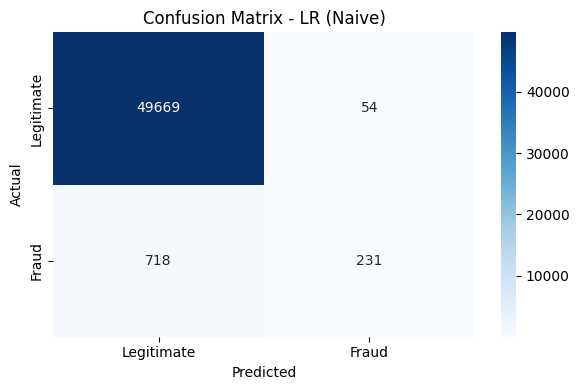

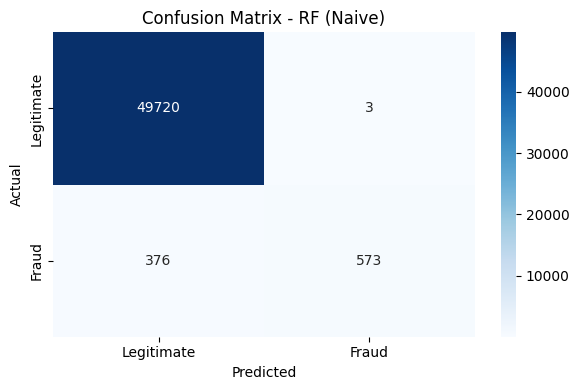

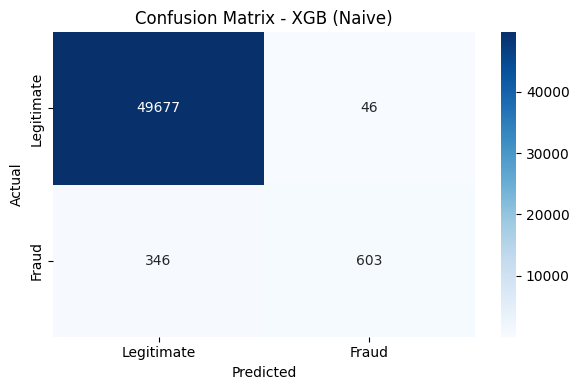

=== BALANCED MODELS ===


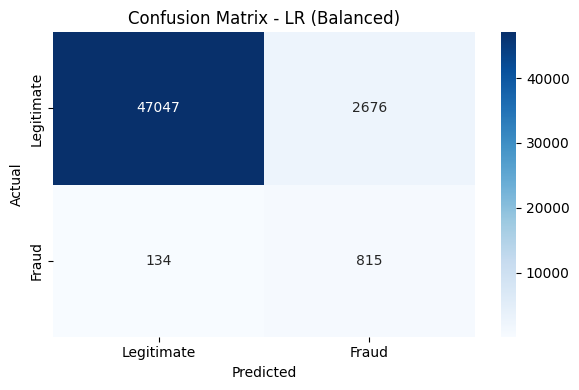

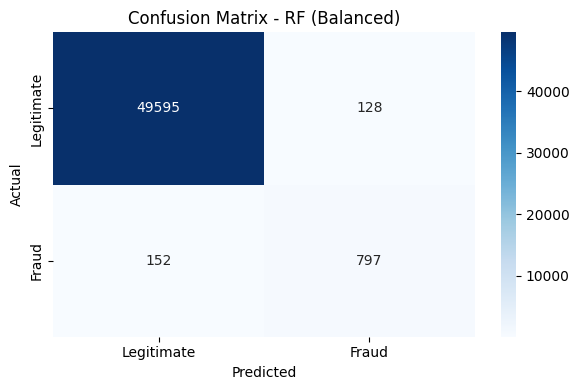

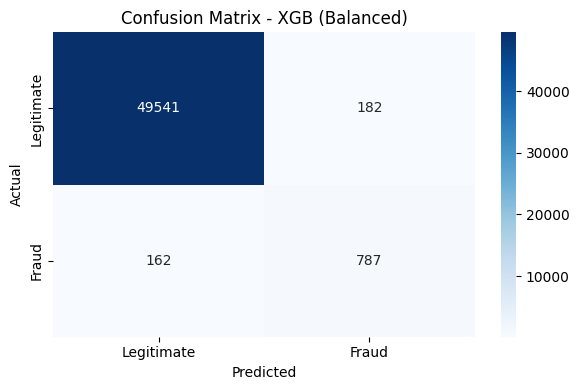

In [9]:
def plot_confusion_matrix(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])

    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

print("=== NAIVE MODELS ===")
plot_confusion_matrix("LR (Naive)", lr_naive, X_test_scaled, y_test)
plot_confusion_matrix("RF (Naive)", rf_naive, X_test_scaled, y_test)
plot_confusion_matrix("XGB (Naive)", xgb_naive, X_test_scaled, y_test)

print("=== BALANCED MODELS ===")
plot_confusion_matrix("LR (Balanced)", lr_model, X_test_scaled, y_test)
plot_confusion_matrix("RF (Balanced)", rf_model, X_test_scaled, y_test)
plot_confusion_matrix("XGB (Balanced)", xgb_model, X_test_scaled, y_test)

Naive models show high false negatives (missed fraud) while balanced models show improved true positive rates at the cost of more false positives.

## Precision-Recall Curves
PR curves are more informative than ROC curves for imbalanced datasets. The area under the PR curve (AUPRC) is the primary model quality metric. Balanced models should show higher AUPRC than naive variants.

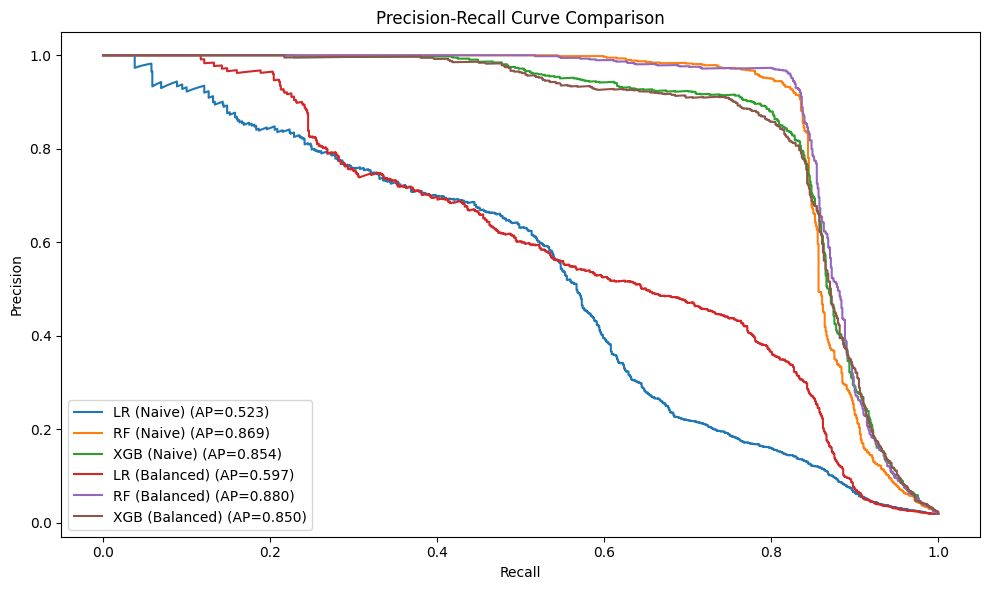

In [10]:
def plot_precision_recall_comparison(models_dict, X_test, y_test, save_path=None):
    plt.figure(figsize=(10, 6))
    
    for name, model in models_dict.items():
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        ap_score = average_precision_score(y_test, y_pred_proba)
        plt.plot(recall, precision, label=f'{name} (AP={ap_score:.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

models = {
    'LR (Naive)': lr_naive,
    'RF (Naive)': rf_naive,
    'XGB (Naive)': xgb_naive,
    'LR (Balanced)': lr_model,
    'RF (Balanced)': rf_model,
    'XGB (Balanced)': xgb_model
}

plot_precision_recall_comparison(models, X_test_scaled, y_test, save_path='../results/pr_curve.png')

## Feature Importance
Random Forest and XGBoost expose feature importances directly. 

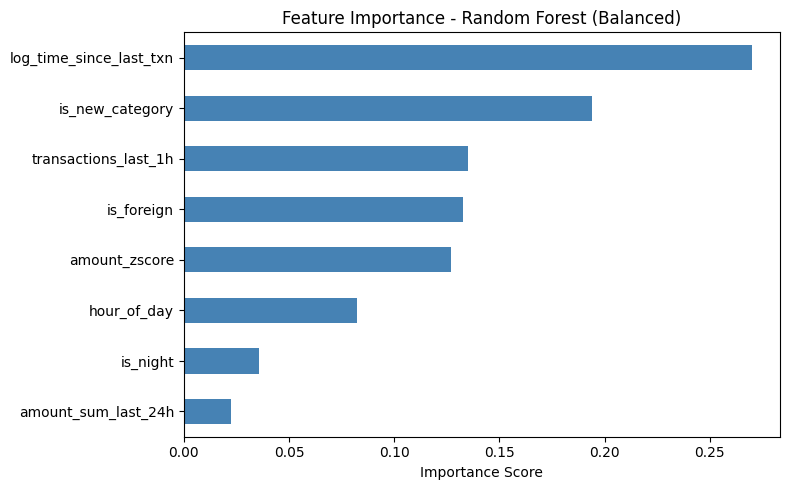

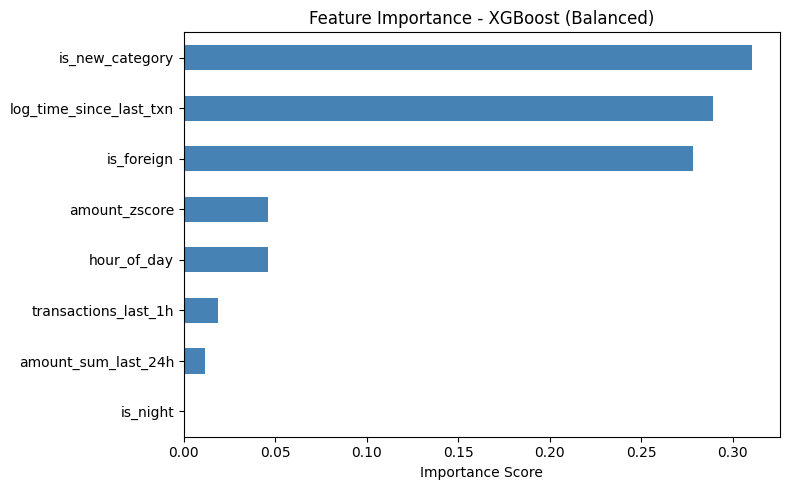

In [11]:
def plot_feature_importance(name, model, feature_cols):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=True)
    
    plt.figure(figsize=(8, 5))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance - {name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

# Only RF and XGBoost have feature_importances_
plot_feature_importance("Random Forest (Balanced)", rf_model, feature_cols)
plot_feature_importance("XGBoost (Balanced)", xgb_model, feature_cols)

This reveals which behavioural signals the models rely on most and which signals an attacker should target to degrade performance.

## Save results
Save baseline metrics and trained models for use in subsequent robustness and retraining notebooks.

In [12]:
results = []
results.append(evaluate_model("LR (Naive)", lr_naive, X_test_scaled, y_test, threshold=0.5))
results.append(evaluate_model("RF (Naive)", rf_naive, X_test_scaled, y_test, threshold=0.5))
results.append(evaluate_model("XGB (Naive)", xgb_naive, X_test_scaled, y_test, threshold=0.5))
results.append(evaluate_model("LR (Balanced)", lr_model, X_test_scaled, y_test, threshold=0.5))
results.append(evaluate_model("RF (Balanced)", rf_model, X_test_scaled, y_test, threshold=0.5))
results.append(evaluate_model("XGB (Balanced)", xgb_model, X_test_scaled, y_test, threshold=0.5))

results_df = pd.DataFrame(results).set_index('name')
results_df = results_df.round(4)
print("\n=== MODEL COMPARISON TABLE ===")
print(results_df.to_string())
results_df.to_csv('../results/baseline_results.csv')
print("\nResults saved to results/baseline_results.csv")


LR (Naive)
--------------------------------------------------
Threshold: 0.5
Precision:  0.8105
Recall:     0.2434
F1 Score:   0.3744
ROC-AUC:    0.9179
Avg Precision: 0.5227
--------------------------------------------------

RF (Naive)
--------------------------------------------------
Threshold: 0.5
Precision:  0.9948
Recall:     0.6038
F1 Score:   0.7515
ROC-AUC:    0.9700
Avg Precision: 0.8692
--------------------------------------------------

XGB (Naive)
--------------------------------------------------
Threshold: 0.5
Precision:  0.9291
Recall:     0.6354
F1 Score:   0.7547
ROC-AUC:    0.9744
Avg Precision: 0.8542
--------------------------------------------------

LR (Balanced)
--------------------------------------------------
Threshold: 0.5
Precision:  0.2335
Recall:     0.8588
F1 Score:   0.3671
ROC-AUC:    0.9278
Avg Precision: 0.5974
--------------------------------------------------

RF (Balanced)
--------------------------------------------------
Threshold: 0.5
Precisi

In [13]:
import joblib
import os

os.makedirs('../results/models', exist_ok=True)

# Save balanced models (primary defenders)
joblib.dump(lr_model, '../results/models/lr_balanced.pkl')
joblib.dump(rf_model, '../results/models/rf_balanced.pkl')
joblib.dump(xgb_model, '../results/models/xgb_balanced.pkl')

# Save naive models (for comparison)
joblib.dump(lr_naive, '../results/models/lr_naive.pkl')
joblib.dump(rf_naive, '../results/models/rf_naive.pkl')
joblib.dump(xgb_naive, '../results/models/xgb_naive.pkl')

# Save scaler
joblib.dump(scaler, '../results/models/scaler.pkl')

print("All models saved successfully!")
print("Saved to results/models/:")
for f in os.listdir('../results/models'):
    print(f"  - {f}")

All models saved successfully!
Saved to results/models/:
  - lr_balanced.pkl
  - lr_naive.pkl
  - rf_balanced.pkl
  - rf_naive.pkl
  - scaler.pkl
  - xgb_balanced.pkl
  - xgb_naive.pkl
